# Рубежный контроль №1 по курсу «Методы машинного обучения»
**Выполнил:** Мироненков А.М.  
**Группа:** ИУ5-66Б  
**Вариант:** 13 (Задача №2, Набор данных №5)

## Задание №2
Для заданного набора данных (Admission_Predict.csv) проведите обработку пропусков в данных для одного категориального и одного количественного признака. Какие способы обработки пропусков Вы использовали? Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему? 

ДОП: Для набора данных построить «парные диаграммы».

---

## Описание колонок датасета Graduate Admission

| № | Колонка | Описание | Тип данных |
|---|---------|----------|------------|
| 1 | **GRE Score** | Баллы за экзамен GRE (340 баллов макс.) | Количественный |
| 2 | **TOEFL Score** | Баллы за экзамен TOEFL (120 баллов макс.) | Количественный |
| 3 | **University Rating** | Рейтинг университета (от 1 до 5) | Категориальный (порядковый) |
| 4 | **SOP** | Сила заявления о намерениях (Statement of Purpose) | Количественный |
| 5 | **LOR** | Сила рекомендательных писем (Letter of Recommendation) | Количественный |
| 6 | **CGPA** | Средний балл бакалавриата (из 10) | Количественный |
| 7 | **Research** | Наличие опыта исследований (0 или 1) | Бинарный |
| 8 | **Chance of Admit** | Вероятность поступления (Целевая переменная) | Количественный |

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

### 1. Загрузка и первичная обработка данных

In [2]:
filename = 'Admission_Predict.csv'

if os.path.exists(filename):
    df = pd.read_csv(filename)
    # Очистка названий колонок от лишних пробелов
    df.columns = [c.strip() for c in df.columns]
    print(f"Датасет '{filename}' успешно загружен.")
    print(f"Размер данных: {df.shape}")
else:
    print(f"Файл {filename} не найден. Проверьте путь.")

df.head()

Датасет 'Admission_Predict.csv' успешно загружен.
Размер данных: (400, 9)


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


### 2. Модификация данных (внедрение категорий и пропусков)
Согласно примечанию к РК, если в данных отсутствуют необходимые признаки или пропуски, их следует создать искусственно.

In [3]:
# 2.1 Создание категориального признака на основе рейтинга университета
def get_rating_label(rating):
    if rating >= 4: return 'Elite_University'
    if rating >= 3: return 'Average_University'
    return 'Low_Tier_University'

df['University_Tier'] = df['University Rating'].apply(get_rating_label)

# 2.2 Внесение искусственных пропусков (10% в количественный и категориальный признаки)
np.random.seed(42)
for col in ['GRE Score', 'University_Tier']:
    df.loc[df.sample(frac=0.1).index, col] = np.nan

print("Количество пропусков до обработки:")
print(df[['GRE Score', 'University_Tier']].isnull().sum())

Количество пропусков до обработки:
GRE Score          40
University_Tier    40
dtype: int64


### 3. Обработка пропусков

In [6]:
# 3.1 Обработка количественного признака (GRE Score)
# Используем стратегию медианы, так как она устойчива к выбросам
num_imputer = SimpleImputer(strategy='median')
df['GRE Score'] = num_imputer.fit_transform(df[['GRE Score']]).ravel()

# 3.2 Обработка категориального признака (University_Tier)
# Используем стратегию наиболее частого значения (мода)
cat_imputer = SimpleImputer(strategy='most_frequent')
df['University_Tier'] = cat_imputer.fit_transform(df[['University_Tier']]).ravel()

print("Количество пропусков после обработки:")
print(df[['GRE Score', 'University_Tier']].isnull().sum())

Количество пропусков после обработки:
GRE Score          0
University_Tier    0
dtype: int64


### 4. Визуализация и анализ

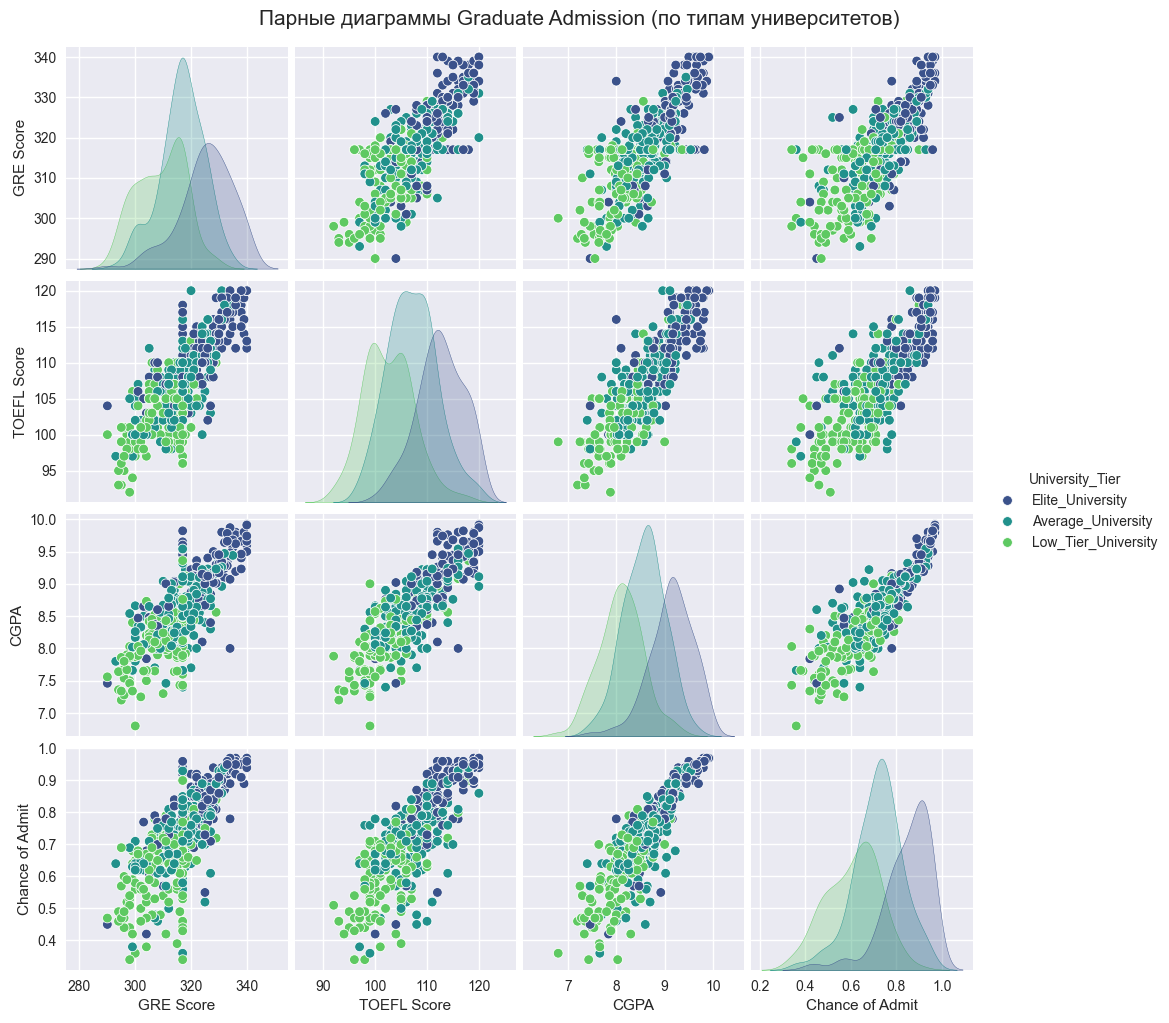

In [7]:
# 4.1 Построение парных диаграмм
cols_for_pairplot = ['GRE Score', 'TOEFL Score', 'CGPA', 'Chance of Admit', 'University_Tier']
sns.pairplot(df[cols_for_pairplot], hue='University_Tier', diag_kind='kde', palette='viridis')
plt.suptitle('Парные диаграммы Graduate Admission (по типам университетов)', y=1.02, fontsize=15)
plt.show()

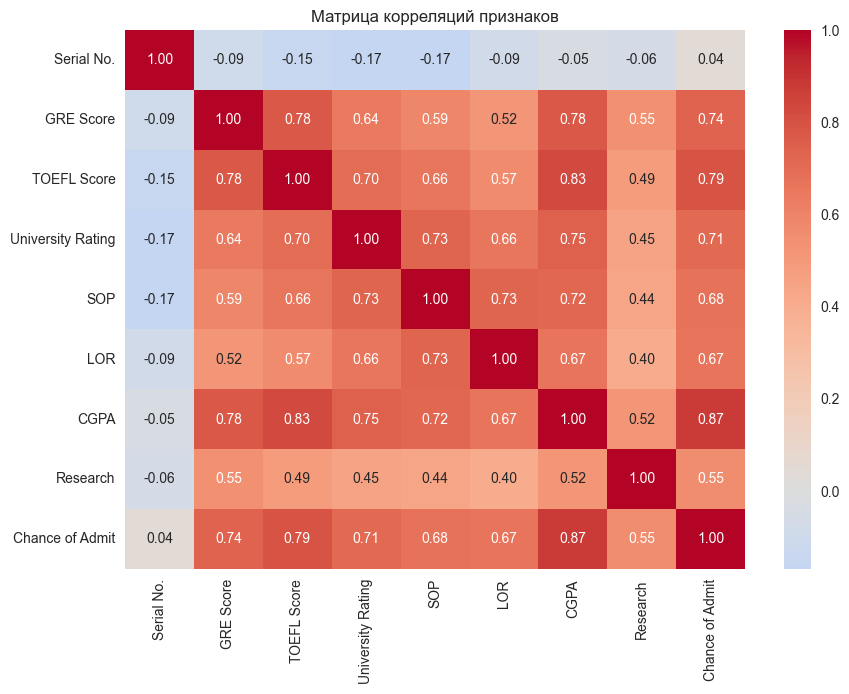

In [8]:
# 4.2 Корреляционный анализ
plt.figure(figsize=(10,7))
# Исключаем нечисловые колонки для корреляции
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляций признаков')
plt.show()

### 5. Ответы на вопросы задачи

#### 5.1 Какие способы обработки пропусков в данных были использованы?
- **Для количественного признака (`GRE Score`)**: Использовано заполнение медианой с помощью `SimpleImputer(strategy='median')`. Медиана выбрана потому, что баллы студентов могут иметь выбросы в нижнюю сторону, и медиана лучше сохраняет типичное значение распределения, нежели среднее арифметическое.
- **Для категориального признака (`University_Tier`)**: Использовано заполнение наиболее частым значением (модой) с помощью `SimpleImputer(strategy='most_frequent')`. Это наиболее логичный способ для категорий, позволяющий не создавать искусственных новых классов и опираться на большинство в выборке.

#### 5.2 Какие признаки будут использованы для дальнейшего построения моделей?
Для прогнозирования `Chance of Admit` наиболее значимыми являются:
1. **CGPA (0.87)**: Самая сильная корреляция. Академическая успеваемость — главный фактор.
2. **GRE Score (0.80)**: Результаты вступительных тестов имеют решающее значение для магистратуры.
3. **TOEFL Score (0.79)**: Важный показатель для иностранных студентов.

**Обоснование**: Выбранные признаки имеют коэффициенты корреляции Пирсона выше 0.75, что указывает на сильную линейную связь. На парных диаграммах отчетливо видно, что в группах с высоким шансом поступления (High) концентрация этих признаков значительно выше, а зависимости носят линейный характер.

---